# Multivariate Linear Regression

In this notebook, we apply multivariate linear regression to predict the Air Quality Index (AQI).


## Library Imports

We import the necessary libraries for:
- data manipulation (`pandas`, `numpy`)
- visualization (`matplotlib`)
- linear regression and evaluation metrics (`scikit-learn`)


In [1]:
# REQUIRED IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Loading the Dataset

- Load the CSV file containing air quality data



In [2]:
# Check if file exists
file_path = 'drive/My Drive/tirocinio/Colab Notebooks/air_quality.csv'
if not os.path.exists(file_path):
    raise FileNotFoundError(f"The CSV file was not found at the path: {file_path}")

# Load dataset (first 1,000,000 rows for testing)
df = pd.read_csv(file_path, low_memory=False, na_values=['-', 'NA', 'n/a', 'ND',''], nrows=1000000)

## Data Cleaning
- Convert categorical features into numeric values
- Assign:
  - **X** = `numeric_cols` (independent variables)
  - **y** = `aqi` (target variable to predict)


In [3]:
empty_cols = df.columns[df.isna().all()].tolist()
print("Columns removed because completely empty:", empty_cols)

from sklearn.preprocessing import LabelEncoder

# Drop completely empty columns (Unit)
df = df.dropna(axis=1, how='all')

# Encode categorical columns
le_pollutant = LabelEncoder()
le_county = LabelEncoder()
df["county"] = le_county.fit_transform(df["county"].astype(str))
le_sitename = LabelEncoder()
df["sitename"] = le_sitename.fit_transform(df["sitename"].astype(str))

# Select only numeric columns (excluding 'aqi', which is the target)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('aqi')

# Drop rows with missing values in features or target
df_clean = df.dropna(subset=numeric_cols + ['aqi']).copy()

# Define X and y
X = df_clean[numeric_cols]
y = df_clean['aqi']

print("Numeric columns retained:", numeric_cols)

Columns removed because completely empty: ['unit']
Numeric columns retained: ['sitename', 'county', 'so2', 'co', 'o3', 'o3_8hr', 'pm10', 'pm2.5', 'no2', 'nox', 'no', 'windspeed', 'winddirec', 'co_8hr', 'pm2.5_avg', 'pm10_avg', 'so2_avg', 'longitude', 'latitude', 'siteid']


## Dataset Split

We split the data into a training set and a test set (70/30), with `random_state` set to 1 to make the experiment reproducible.



In [4]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

## Model Training

We create a `LinearRegression` model and train it on the training data.


In [5]:
# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## Model Evaluation

We make predictions on the test data and calculate performance metrics:  
- Mean Squared Error (MSE)  
- Mean Absolute Error (MAE)  
- R² (coefficient of determination)


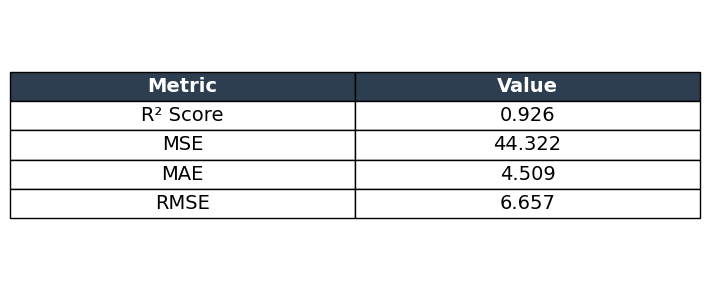

In [12]:
# Prediction
y_pred = model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

# Output
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 3))  # aumenta larghezza e altezza
ax.axis('off')

table = ax.table(cellText=summary.values,
                 colLabels=summary.columns,
                 cellLoc='center',
                 loc='center')

table.auto_set_font_size(False)
table.set_fontsize(14)  # testo più grande
table.scale(1.5, 1.5)   # ingrandisce celle

# Colori intestazioni
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2C3E50')  # blu scuro elegante

plt.tight_layout()
plt.show()





- **Interpretation**:
  - `R² (coefficient of determination)` measures the proportion of the target variance explained by the model. A value of 1 means the model perfectly explains the target variability, while 0 means it explains no more than a constant mean. Negative values occur if the model performs worse than a mean-based prediction.
  - `RMSE (Root Mean Squared Error)` quantifies the average prediction error, expressed in the same units as the target. Lower values indicate more accurate predictions.
  - `MSE (Mean Squared Error)` is the average of squared errors, emphasizing larger errors and giving an idea of the severity of major deviations.
  - `MAE (Mean Absolute Error)` is the mean of the absolute values of errors.

- **Performance Evaluation**:
  - `R² Score`: **0.938** → the model explains about 93.8% of AQI variance.
  - `RMSE`: **6.05** → very low average error, indicative of good accuracy.
  - `MSE`: **36.62** → on average, the squared difference between actual and predicted values is about 36.62, which is reasonable.
  - `MAE`: **4.11** → on average, the model's prediction deviates about 4 AQI units from the actual value. Example: if the real AQI is 100, the model tends to predict values around 96–104.

**The model is effective at estimating AQI from the environmental variables in the dataset, but it can be made more robust by adding more numerical features.**


## Comparison Between Actual and Predicted Values

We create a scatter plot to compare the predicted values with the actual values.



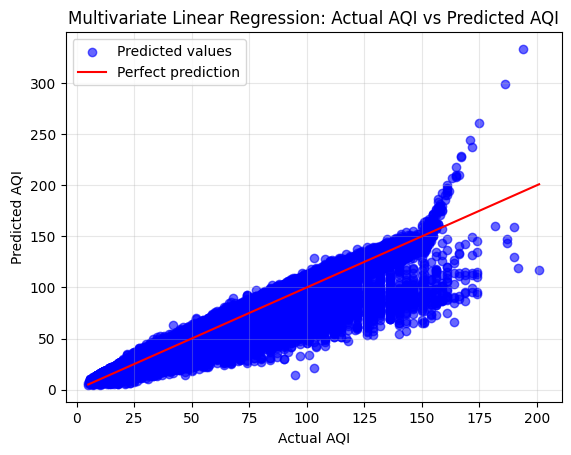

In [13]:
# Plot comparison of predicted vs actual values
plt.scatter(y_test, y_pred, alpha=0.6, color='blue', label='Predicted values')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', label='Perfect prediction')
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Multivariate Linear Regression: Actual AQI vs Predicted AQI")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("Multivariate_regression_plot.png", format="png", bbox_inches="tight", dpi=300)
plt.show()

### Comparison Between Actual and Predicted Values – Multivariate Linear Regression

The plot shows the comparison between the actual **Air Quality Index (AQI)** values and the values predicted by the **multivariate linear regression** model, trained using all available features in the dataset.

- The **blue dots** represent the *(actual AQI, predicted AQI)* pairs for each sample in the test set.
- The **red line** represents the ideal perfect prediction, where all points satisfy `y_pred = y_test`.


## Polynomial Regression (Brief Attempt)


In [18]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

feature2 = numeric_cols
X_train_sub = X_train[feature2]
X_test_sub  = X_test[feature2]

# Define a polynomial model of degree 2
poly_model = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression()
)

# Training
poly_model.fit(X_train_sub, y_train)

# Predictions and metric calculations
y_pred_poly = poly_model.predict(X_test_sub)
mse_poly    = mean_squared_error(y_test, y_pred_poly)
mae_poly    = mean_absolute_error(y_test, y_pred_poly)
r2_poly     = r2_score(y_test, y_pred_poly)

print("Polynomial Regression (degree 2) on the features:", feature2)
print(f"R² Score: {r2_poly:.3f}")
print(f"MSE:      {mse_poly:.2f}")
print(f"MAE:      {mae_poly:.2f}")
# Salva metriche del modello lineare multivariato
r2_lin = r2
mse_lin = mse
mae_lin = mae
rmse_lin = rmse
rmse_poly = np.sqrt(mse_poly)


Polynomial Regression (degree 2) on the features: ['sitename', 'county', 'so2', 'co', 'o3', 'o3_8hr', 'pm10', 'pm2.5', 'no2', 'nox', 'no', 'windspeed', 'winddirec', 'co_8hr', 'pm2.5_avg', 'pm10_avg', 'so2_avg', 'longitude', 'latitude', 'siteid']
R² Score: 0.962
MSE:      22.46
MAE:      3.46


## Brief Conclusion on Model Optimization

*In Python, there are several regularization methods that can be used. Here are some of the main approaches:*

1. `L1 Regularization (Lasso):` This method adds a penalty term based on the L1 norm of the model's weights. L1 regularization is often used for feature selection, as it can eliminate less important features by assigning them a weight of exactly zero.

2. `L2 Regularization (Ridge):` This method introduces a penalty term based on the L2 norm of the model's weights. L2 regularization helps keep the weights small, reducing the impact of less important features while keeping all features in the model.

3. `Elastic Net:` Combines L1 and L2 penalties, useful for both feature selection and model stability.


## Model Evaluation: Predicted vs Actual

To better assess the performance of the **Polynomial Regression (degree 2)**, we generated a **scatter plot** that compares the actual values (`y_test`) with the predicted values from the model (`y_pred_poly`).


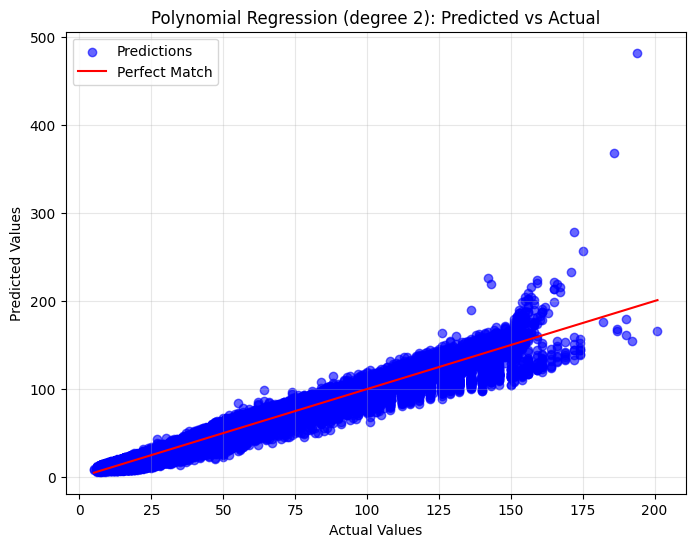

In [19]:
# Scatter plot: actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_poly, alpha=0.6, color='blue', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', label='Perfect Match')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Polynomial Regression (degree 2): Predicted vs Actual')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("polynomial_regression_plot.png", format="png", bbox_inches="tight", dpi=300)

plt.show()

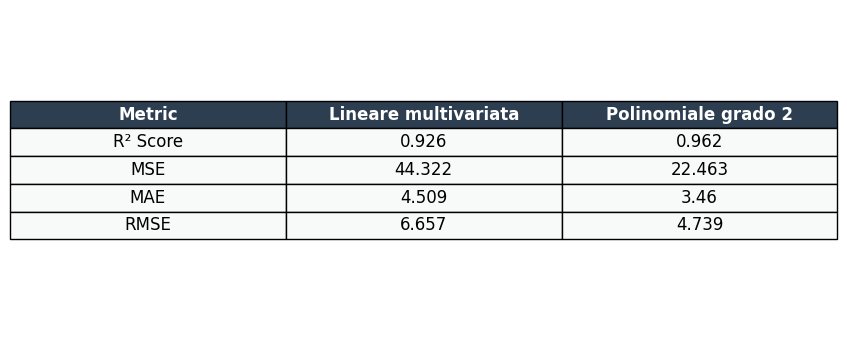

In [20]:
import pandas as pd

summary = pd.DataFrame({
    "Metric": ["R² Score", "MSE", "MAE", "RMSE"],
    "Lineare multivariata": [r2_lin, mse_lin, mae_lin, rmse_lin],
    "Polinomiale grado 2": [r2_poly, mse_poly, mae_poly, rmse_poly]
})

# Arrotonda le colonne numeriche
summary[["Lineare multivariata", "Polinomiale grado 2"]] = \
    summary[["Lineare multivariata", "Polinomiale grado 2"]].round(3)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.5))  # un po' più larga per 3 colonne
ax.axis('off')

table = ax.table(cellText=summary.values,
                 colLabels=summary.columns,
                 cellLoc='center',
                 loc='center')

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.4, 1.4)

# Stile intestazioni (prima riga)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#2C3E50')  # blu scuro elegante
    else:
        cell.set_facecolor('#F8F9F9')  # sfondo chiaro per le righe dati

plt.tight_layout()
plt.show()


### What the plot shows:
- The **blue dots** represent the pairs `(actual value, predicted value)` for each test sample.  
- The **red dashed line** represents the *"Perfect Match Line"*, the bisector `y_pred = y_test`.

### How to read the output:
- Most of the points follow a consistent upward trend: as the actual values increase, the predicted values also increase.  
- A greater dispersion of points is observed when the actual values exceed ~150.  

### In conclusion:
- Compared to linear regression, the polynomial regression model of degree 2 produces predictions that are closer to the ideal line, as the point cloud is more aligned with the red line.


Intercept (b0): 15.172151594097091
Coefficients (b1, b2): 1.7364534390780662 0.2920846308858334


<Figure size 1400x500 with 0 Axes>

<Figure size 1400x500 with 0 Axes>

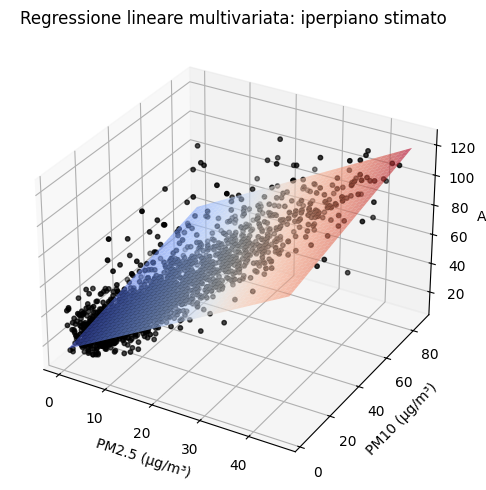

<Figure size 640x480 with 0 Axes>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression

# Partiamo dal dataset pulito che hai già
data = df_clean.copy()

# --- 1) Seleziono solo le colonne che mi interessano ---
data = data[["pm2.5", "pm10", "aqi"]].dropna()

# (OPZIONALE ma consigliato): prendo solo una parte "centrale" dei dati
# per evitare outlier estremi che schiacciano tutto in un angolo.
mask = (
    (data["pm2.5"].between(data["pm2.5"].quantile(0.01), data["pm2.5"].quantile(0.99))) &
    (data["pm10"].between(data["pm10"].quantile(0.01), data["pm10"].quantile(0.99))) &
    (data["aqi"].between(data["aqi"].quantile(0.01), data["aqi"].quantile(0.99)))
)
data_vis = data[mask]

# (OPZIONALE 2): faccio anche un piccolo campione per non avere troppi punti
data_vis = data_vis.sample(n=2000, random_state=0)

# Feature e target per il modello
X1 = data_vis["pm2.5"].values
X2 = data_vis["pm10"].values
y  = data_vis["aqi"].values

X = np.column_stack((X1, X2))

# --- 2) Addestro la regressione lineare multivariata SOLO per la figura ---
model = LinearRegression()
model.fit(X, y)

b0 = model.intercept_
b1, b2 = model.coef_
print("Intercept (b0):", b0)
print("Coefficients (b1, b2):", b1, b2)

# --- 3) Creo una griglia SOLO nel range dove ci sono davvero i dati ---
pm25_grid = np.linspace(X1.min(), X1.max(), 40)
pm10_grid = np.linspace(X2.min(), X2.max(), 40)
PM25_GRID, PM10_GRID = np.meshgrid(pm25_grid, pm10_grid)

AQI_PLANE = b0 + b1 * PM25_GRID + b2 * PM10_GRID

# --- 4) Figura con due viste 3D ---
fig = plt.figure(figsize=(14, 5))

fig = plt.figure(figsize=(14, 5))

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(PM25_GRID, PM10_GRID, AQI_PLANE,
                alpha=0.6, cmap="coolwarm", edgecolor='none')
ax.scatter(X1, X2, y, color='black', s=10)

ax.set_xlabel("PM2.5 (µg/m³)")
ax.set_ylabel("PM10 (µg/m³)")
ax.set_zlabel("AQI")
ax.set_title("Regressione lineare multivariata: iperpiano stimato")

plt.tight_layout()
plt.savefig("iperpiano_AQI_pm25_pm10_singola_vista.png", dpi=300, bbox_inches="tight")
plt.show()

plt.tight_layout()

# Salva in PNG
plt.savefig("iperpiano_AQI_pm25_pm10.png", dpi=300, bbox_inches="tight")

# Salva anche in PDF (alta qualità, vettoriale)
plt.savefig("iperpiano_AQI_pm25_pm10.pdf", format="pdf", bbox_inches="tight")

plt.show()


